# 1 — Data Exploration

This notebook downloads (or loads) PJM hourly LMP and weather data,
then performs exploratory analysis to understand the statistical
properties of electricity prices in the PJM market.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.insert(0, os.path.abspath("../src"))

# Use either real data or the demo dataset
# Option A: Load real downloaded data (run `make download` first)
from pjm_spike_forecast.data import load_lmp, load_weather, merge_lmp_weather
lmp = load_lmp("../data/raw/nyiso_lmp.csv")
weather = load_weather("../data/raw/weather.csv")
df = merge_lmp_weather(lmp, weather)

# Option B: Demo dataset (works immediately, no download needed)
# from pjm_spike_forecast.data import build_demo_dataset
# df = build_demo_dataset(n_days=365, seed=42)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()

Dataset shape: (26293, 8)
Date range: 2022-01-01 05:00:00+00:00 → 2024-12-31 23:00:00+00:00


,lmp,congestion,loss,energy,temperature_c,relative_humidity,wind_speed_kmh,precipitation_mm
datetime_utc,,,,,,,,
2022-01-01 05:00:00+00:00,28.785455,0.000000,2.016364,26.769091,7.9,100,5.1,0.0
2022-01-01 06:00:00+00:00,24.253333,-18.810000,0.402500,42.660833,8.0,100,4.2,0.0
2022-01-01 07:00:00+00:00,26.859167,-16.808333,0.726667,42.940833,7.7,100,6.4,0.0
2022-01-01 08:00:00+00:00,22.192500,-9.110000,0.965833,30.336667,7.7,100,4.7,0.1
2022-01-01 09:00:00+00:00,26.762500,-1.529167,1.781667,26.510000,7.8,100,9.1,0.1


## 1.1 — LMP Distribution

PJM prices are known to have a heavy right tail — most hours
trade between \$20–40/MWh, but occasional spikes reach \$100+.

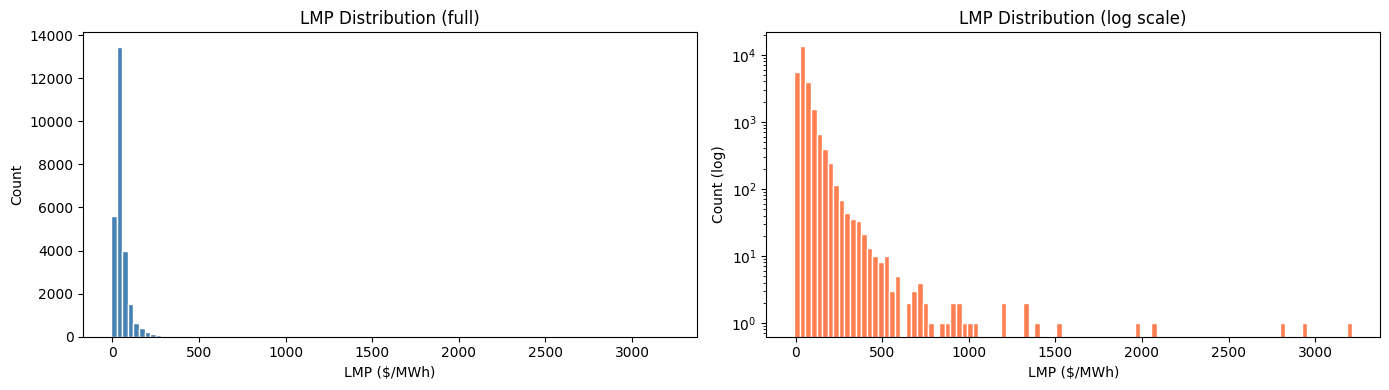

Mean:   $53.42/MWh
Median: $36.84/MWh
Std:    $65.80/MWh
Max:    $3213.21/MWh
Skew:   16.64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
axes[0].hist(df["lmp"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_xlabel("LMP ($/MWh)")
axes[0].set_ylabel("Count")
axes[0].set_title("LMP Distribution (full)")

# Log-scale to see the tail
axes[1].hist(df["lmp"], bins=100, color="coral", edgecolor="white", log=True)
axes[1].set_xlabel("LMP ($/MWh)")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("LMP Distribution (log scale)")

plt.tight_layout()
plt.show()

print(f"Mean:   ${df['lmp'].mean():.2f}/MWh")
print(f"Median: ${df['lmp'].median():.2f}/MWh")
print(f"Std:    ${df['lmp'].std():.2f}/MWh")
print(f"Max:    ${df['lmp'].max():.2f}/MWh")
print(f"Skew:   {df['lmp'].skew():.2f}")

## 1.2 — Diurnal Pattern

Electricity demand (and price) follows a strong daily cycle:
peak during business hours (10am–6pm), trough overnight.

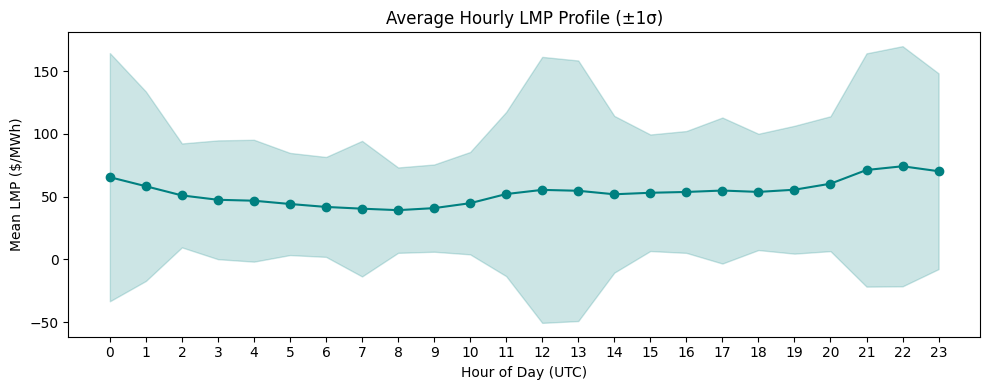

In [11]:
hourly_avg = df.groupby(df.index.hour)["lmp"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_avg.index, hourly_avg["mean"], "o-", color="teal")
ax.fill_between(hourly_avg.index,
                hourly_avg["mean"] - hourly_avg["std"],
                hourly_avg["mean"] + hourly_avg["std"],
                alpha=0.2, color="teal")
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Mean LMP ($/MWh)")
ax.set_title("Average Hourly LMP Profile (±1σ)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 1.3 — Seasonal Pattern

PJM prices are higher in summer (cooling demand) and winter
(heating demand), creating a U-shaped seasonal profile.

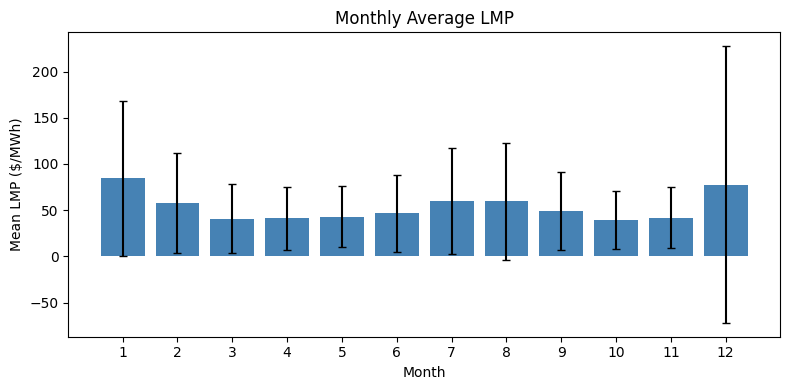

In [12]:
monthly_avg = df.groupby(df.index.month)["lmp"].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_avg.index, monthly_avg["mean"], color="steelblue",
       yerr=monthly_avg["std"], capsize=3)
ax.set_xlabel("Month")
ax.set_ylabel("Mean LMP ($/MWh)")
ax.set_title("Monthly Average LMP")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 1.4 — Temperature vs LMP

The relationship is U-shaped: both very cold and very hot
temperatures drive up demand (heating/cooling) and price.

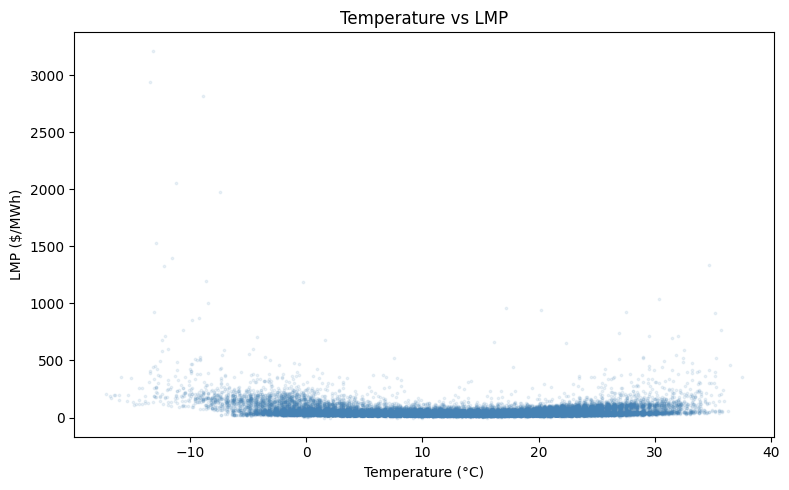

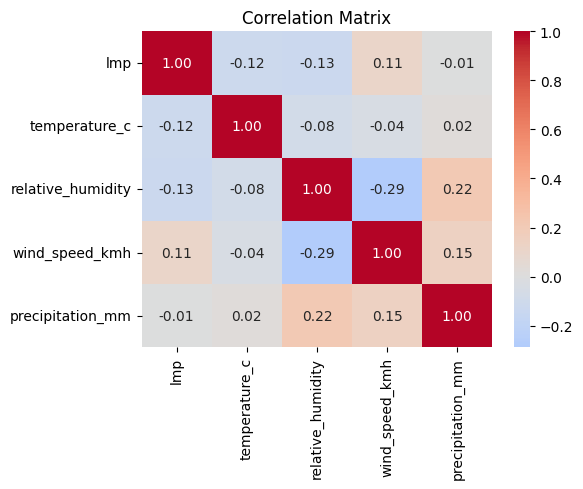

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["temperature_c"], df["lmp"], alpha=0.1, s=3, color="steelblue")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("LMP ($/MWh)")
ax.set_title("Temperature vs LMP")
plt.tight_layout()
plt.show()

# Correlation matrix
weather_cols = ["temperature_c", "relative_humidity", "wind_speed_kmh", "precipitation_mm"]
corr_cols = ["lmp"] + [c for c in weather_cols if c in df.columns]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 1.5 — Autocorrelation

LMP has strong autocorrelation at lag-1h, lag-24h (daily cycle),
and lag-168h (weekly cycle).

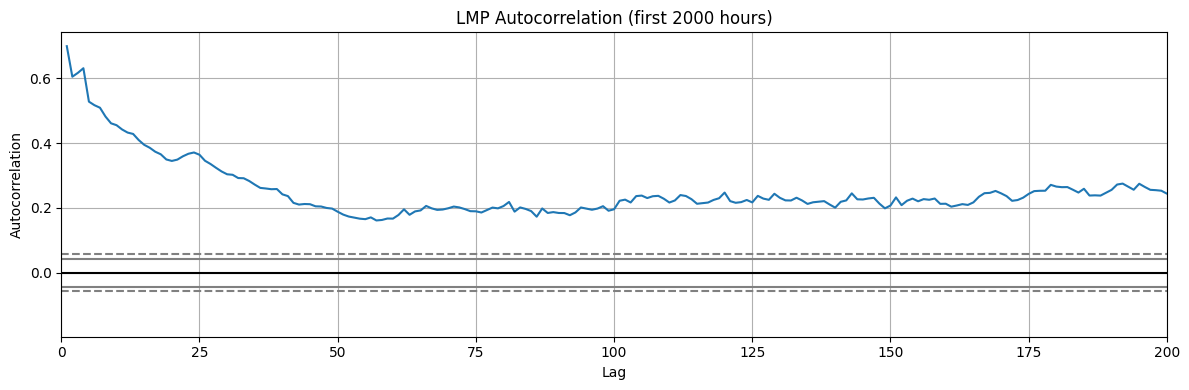

In [14]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(figsize=(12, 4))
pd.plotting.autocorrelation_plot(df["lmp"].iloc[:2000], ax=ax)
ax.set_xlim(0, 200)
ax.set_title("LMP Autocorrelation (first 2000 hours)")
plt.tight_layout()
plt.show()